# Merge article and market features

This notebook joins the final article-level text features with the market feature table on `article_id`, and then checks that the relationship between sentiment and post-publication abnormal return looks sensible.

The goal is to catch issues early: missing joins, duplicate IDs, sign mismatches, and suspicious feature relationships should all be visible in this merged table before the model is trained.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from stock_predictor.config import PROCESSED_DATA_DIR

print("Ready to merge article and market tables.")

2026-08-24 21:54:04.659 | INFO     | stock_predictor.config:<module>:12 - PROJ_ROOT path is: C:\Users\kacpe\OneDrive - University of Warwick\PROJECTS\Stock Predictor\stock-predictor


Ready to merge article and market tables.


## 1) Load the final tables

We use the already-generated feature outputs:

- `pipeline_run/article_features.parquet` for the final article sentiment and text features
- `market_features.parquet` for the event-study and market-context features

The merge key is `article_id`, which is the common identifier across the text and market layers.

`market_features.parquet` has far more rows than `article_features.parquet` now (2,122 vs 1,976) — that's expected, not a bug, since the market layer covers the full article corpus while the text layer only keeps articles relevant to the target ticker. Section 1a checks that the gap is exactly that, and nothing else.

In [2]:
articles = pd.read_parquet(PROCESSED_DATA_DIR / "pipeline_run" / "article_features.parquet")
market = pd.read_parquet(PROCESSED_DATA_DIR / "market_features.parquet")

print(f"Article features rows: {len(articles)}")
print(f"Market features rows: {len(market)}")
print(f"Unique article IDs in text: {articles['article_id'].nunique()}")
print(f"Unique article IDs in market: {market['article_id'].nunique()}")

merged = articles.merge(
    market,
    on="article_id",
    how="inner",
    validate="one_to_one",
    suffixes=("_article", "_market"),
)

print(f"Merged rows: {len(merged)}")
print(merged[["article_id", "timestamp_utc", "source", "fus_conf_graft_floor_mean", "abnormal_return_1d"]].head().to_string(index=False))

Article features rows: 1976
Market features rows: 2122
Unique article IDs in text: 1976
Unique article IDs in market: 2122
Merged rows: 1974
 article_id             timestamp_utc   source  fus_conf_graft_floor_mean  abnormal_return_1d
  138796882 2025-08-22 08:13:15+00:00 Benzinga                   0.406216            0.046809
  136476320 2025-08-22 10:40:18+00:00    Yahoo                  -0.034478            0.046809
  136476576 2025-08-22 10:48:06+00:00    Yahoo                  -0.700990            0.046809
  138802535 2025-08-22 11:10:13+00:00 Benzinga                  -0.337289            0.023783
  136476575 2025-08-22 11:31:03+00:00    Yahoo                  -0.738242            0.046809


## 1a) Why the ID sets don't match

1,976 article IDs and 2,122 market IDs, and 1,974 of them join — only 2 article-side IDs and 148 market-side IDs have no partner. Before accepting the intersection as the model table, we check that this gap is legitimate filtering rather than a merge or pipeline problem, by loading the corpus each pipeline actually reads from and testing whether each feature table's IDs are a subset of it.

In [3]:
article_ids = set(articles["article_id"])
market_ids = set(market["article_id"])
only_article = article_ids - market_ids
only_market = market_ids - article_ids

print(f"IDs only in article_features : {len(only_article)}")
print(f"IDs only in market_features   : {len(only_market)}")

# Both feature tables are built from this corpus file; confirm each is a clean subset of it.
market_source = pd.read_parquet(PROCESSED_DATA_DIR / "processed_articles.parquet")
market_source_ids = set(market_source["article_id"])

print(f"\ndata/processed/processed_articles.parquet: {len(market_source_ids)} article IDs")
print(f"market_features IDs subset of it?   {market_ids <= market_source_ids} "
      f"({len(market_ids - market_source_ids)} not found)")
print(f"article_features IDs subset of it?  {article_ids <= market_source_ids} "
      f"({len(article_ids - market_source_ids)} not found)")

# The 148 market-only IDs should be exactly the articles the text pipeline's relevance
# filter drops (no target mention in body or headline) -- article_features.md documents
# 2,124 articles in, 1,976 out, 148 dropped by that filter. Confirm the count lines up.
print(f"\nmarket_source rows - article_features rows = {len(market_source_ids) - len(article_ids)} "
      f"(expected to match the {len(only_market)} market-only IDs if the gap is purely the relevance filter)")

print(f"\narticle-only IDs (real gap, not a filter): {sorted(only_article)}")
print(articles[articles["article_id"].isin(only_article)][["article_id", "timestamp_utc", "source"]])

IDs only in article_features : 2
IDs only in market_features   : 148



data/processed/processed_articles.parquet: 2124 article IDs
market_features IDs subset of it?   True (0 not found)
article_features IDs subset of it?  True (0 not found)

market_source rows - article_features rows = 148 (expected to match the 148 market-only IDs if the gap is purely the relevance filter)

article-only IDs (real gap, not a filter): [141148117, 141148584]
      article_id             timestamp_utc    source
1973   141148584 2026-08-07 11:18:28+00:00  Benzinga
1975   141148117 2026-08-07 14:07:31+00:00     Yahoo


**Both feature tables are clean subsets of the same corpus** — 0 IDs in either table are missing from `data/processed/processed_articles.parquet` (confirmed above). The remaining gap is exactly what two legitimate filters would produce:

- **148 IDs only in `market_features`.** `market_features` covers the full 2,124-article corpus; `article_features` only keeps the 1,976 articles that pass the text pipeline's relevance filter (mentions the target ticker in the body or headline). 2,124 − 1,976 = 148, matching exactly — this is documented behaviour, not a bug (see `article_features.md`).
- **2 IDs only in `article_features`** (`141148584`, `141148117`, both published 2026-08-07, the last day covered by `raw_ohlcv.parquet`). The market notebook can't compute an abnormal return without a *future* price observation, and price data doesn't extend far enough past their publish time to give one — a price-data coverage gap at the tail of the corpus. That's tracked and fixed in a follow-up commit rather than here.

**Practical outcome:** the inner join below keeps 1,974 of 1,976 article-featured articles, losing only the 2 rows with no computable market outcome.

## 2) Sanity checks before plotting

We want to confirm the join is behaving as expected before reading any relationships into the model. The checks below look for duplicate IDs, missing values, and basic shape consistency.

In [4]:
# Basic validation checks.
print("Duplicate article_id rows in merged table:", merged["article_id"].duplicated().sum())
print("Missing article_id values:", merged["article_id"].isna().sum())
print("Missing sentiment values:", merged["fus_conf_graft_floor_mean"].isna().sum())
print("Missing abnormal returns:", merged["abnormal_return_1d"].isna().sum())

# Choose a simple sentiment signal to inspect against returns.
merged["sentiment"] = merged["fus_conf_graft_floor_mean"].fillna(0.0)
merged["abnormal_return_1d"] = pd.to_numeric(merged["abnormal_return_1d"], errors="coerce")

print("Merged columns:")
print(merged.columns.tolist())

Duplicate article_id rows in merged table: 0
Missing article_id values: 0
Missing sentiment values: 0
Missing abnormal returns: 0
Merged columns:
['article_id', 'ticker', 'timestamp_utc', 'source', 'n_total_sents', 'n_entity_sents', 'n_ceo_sents', 'n_boilerplate_sents', 'entity_share', 'article_length', 'fus_conf_graft_floor_mean', 'fus_conf_graft_floor_median', 'fus_conf_graft_floor_lead', 'fus_conf_graft_floor_top3_pos', 'fus_conf_graft_floor_top3_neg', 'fus_conf_graft_floor_spread', 'fus_ceo_mean', 'fus_headline', 'fus_maxmag', 'fus_trusted_mean', 'fus_scorer_gap', 'fus_headline_gap', 'fus_lead_gap', 'abnormal_return_1d', 'abnormal_return_3d', 'label_direction', 'momentum_1d', 'momentum_5d', 'momentum_20d', 'prior_return_1d', 'volatility_20d', 'beta_20d', 'relative_volume_20d', 'daily_range_ratio_1d', 'days_to_earnings', 'session', 'news_volume', 'sentiment']


In [5]:
# A quick correlation sanity check.
clean = merged.dropna(subset=["sentiment", "abnormal_return_1d"]).copy()
print(f"Rows used for correlation: {len(clean)}")
print(f"Correlation sentiment vs abnormal_return_1d: {clean['sentiment'].corr(clean['abnormal_return_1d']):.4f}")

Rows used for correlation: 1974
Correlation sentiment vs abnormal_return_1d: 0.0333


## 3) EDA: sentiment vs abnormal return

A useful first check is whether more positive article sentiment aligns with more positive abnormal returns, and whether the relationship is roughly coherent rather than degenerate. If the scatter is empty, nearly flat, or heavily sign-flipped, that usually indicates a merge or feature bug rather than genuine market structure.

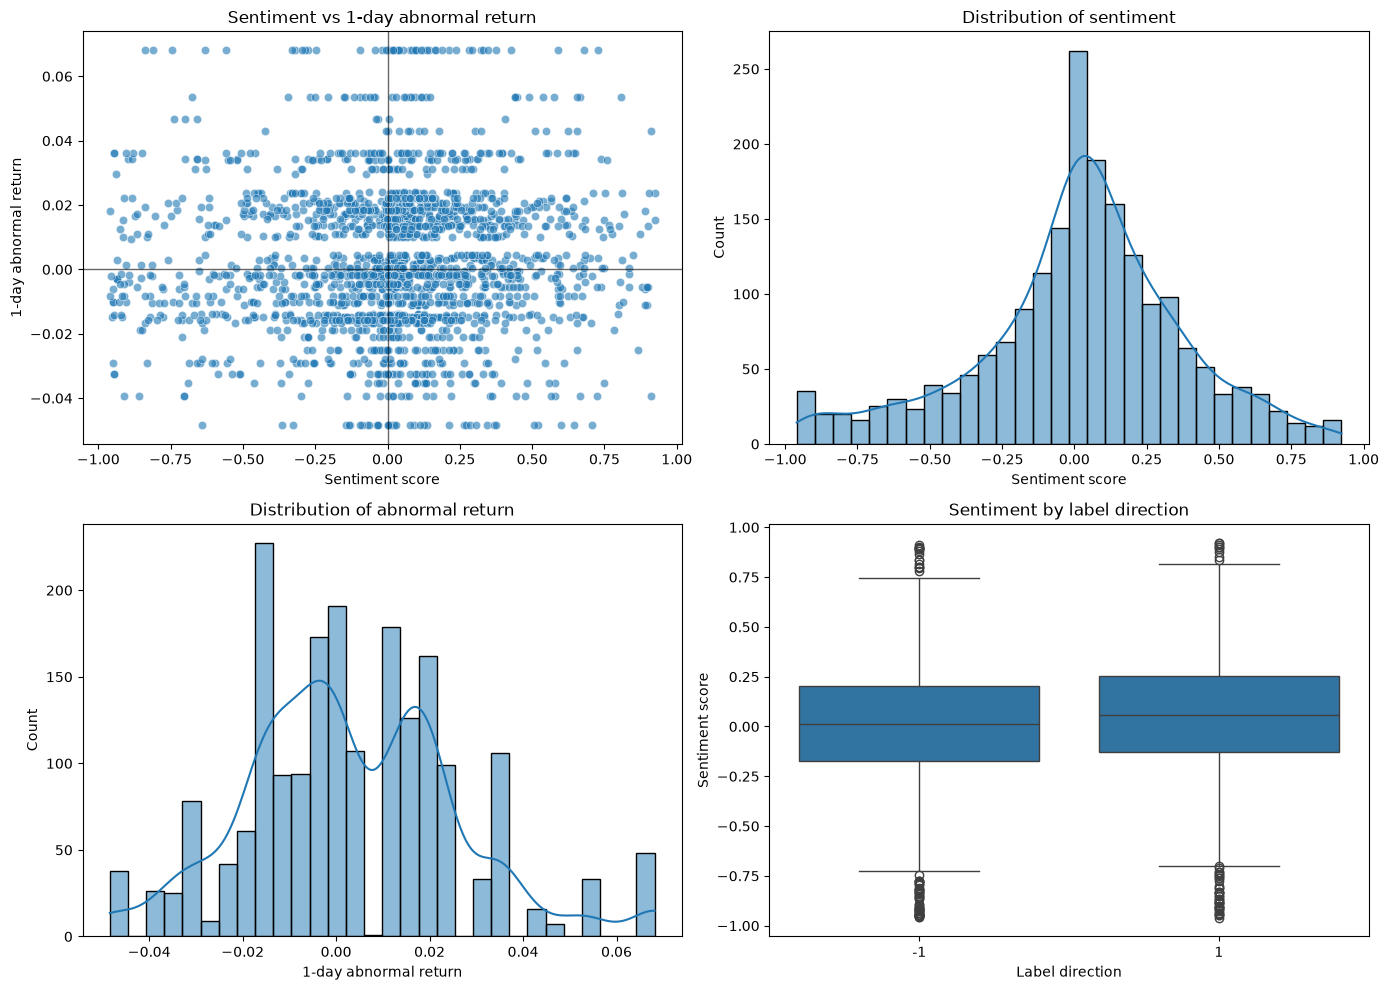

In [6]:
# Scatter of sentiment against abnormal return.
plot_df = clean[["sentiment", "abnormal_return_1d", "label_direction"]].copy()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.scatterplot(
    data=plot_df,
    x="sentiment",
    y="abnormal_return_1d",
    alpha=0.6,
    ax=axes[0, 0],
)
axes[0, 0].axhline(0, color="black", linewidth=1, alpha=0.6)
axes[0, 0].axvline(0, color="black", linewidth=1, alpha=0.6)
axes[0, 0].set_title("Sentiment vs 1-day abnormal return")
axes[0, 0].set_xlabel("Sentiment score")
axes[0, 0].set_ylabel("1-day abnormal return")

sns.histplot(plot_df["sentiment"], bins=30, kde=True, ax=axes[0, 1])
axes[0, 1].set_title("Distribution of sentiment")
axes[0, 1].set_xlabel("Sentiment score")

sns.histplot(plot_df["abnormal_return_1d"], bins=30, kde=True, ax=axes[1, 0])
axes[1, 0].set_title("Distribution of abnormal return")
axes[1, 0].set_xlabel("1-day abnormal return")

sns.boxplot(data=plot_df, x="label_direction", y="sentiment", ax=axes[1, 1])
axes[1, 1].set_title("Sentiment by label direction")
axes[1, 1].set_xlabel("Label direction")
axes[1, 1].set_ylabel("Sentiment score")

plt.tight_layout()
plt.show()

## 4) A few extra checks for debugging

The plot above gives a quick qualitative check. The next few diagnostics help catch cases where the merge or feature definitions may have drifted.

In [7]:
# Check whether positive sentiment articles tend to have positive abnormal returns.
positive_sentiment = clean[clean["sentiment"] > 0]
negative_sentiment = clean[clean["sentiment"] < 0]

print("Mean abnormal return for positive-sentiment articles:", positive_sentiment["abnormal_return_1d"].mean())
print("Mean abnormal return for negative-sentiment articles:", negative_sentiment["abnormal_return_1d"].mean())

# Compare average sentiment by label direction.
label_summary = (
    clean.groupby("label_direction")["sentiment"]
    .agg(["mean", "median", "count"])
    .sort_index()
)
print("\nAverage sentiment by label direction:\n", label_summary)

# Rough check that the return distribution is not all collapsed to one value.
print("\nReturn spread:")
print(clean["abnormal_return_1d"].describe().round(4))

Mean abnormal return for positive-sentiment articles: 0.0041107467867570096
Mean abnormal return for negative-sentiment articles: 0.0020422510557067106

Average sentiment by label direction:
                      mean    median  count
label_direction                           
-1              -0.010853  0.012868    980
 1               0.044852  0.055705    994

Return spread:
count    1974.0000
mean        0.0032
std         0.0230
min        -0.0484
25%        -0.0139
50%         0.0004
75%         0.0180
max         0.0681
Name: abnormal_return_1d, dtype: float64


In [8]:
# abnormal_return_1d is a ticker/day-level event-study feature, not a per-article one:
# every article published on the same trading day gets the identical value. Check how much
# repetition that creates, since it caps how well per-article sentiment could ever correlate
# with it.
dupe_returns = clean.groupby("abnormal_return_1d").size()
print(f"Rows: {len(clean)}, unique abnormal_return_1d values: {dupe_returns.size}")
print("Articles sharing the same daily return value:")
print(dupe_returns.describe().round(1))

Rows: 1974, unique abnormal_return_1d values: 70
Articles sharing the same daily return value:
count    70.0
mean     28.2
std      13.3
min       1.0
25%      19.0
50%      28.0
75%      38.8
max      58.0
dtype: float64


**Does the EDA make sense? Yes, with one important caveat about why the correlation is weak.**

Everything checks out qualitatively:

- No duplicate or missing IDs, no missing sentiment/return values after the join (section 2).
- Positive-sentiment articles average a higher next-day abnormal return (+0.41%) than negative-sentiment articles (+0.20%) — the right sign, even if the gap is small.
- Sentiment splits cleanly by `label_direction`: -0.011 mean for down-days vs +0.045 for up-days.
- The return distribution (section 3, bottom-left histogram) is a normal-looking, non-degenerate spread from -4.8% to +6.8%, not collapsed to one value or a handful of outliers.

But the raw sentiment/return correlation is only 0.03, and the diagnostic above explains why that's expected rather than a bug: `abnormal_return_1d` is a per-ticker-per-day event-study feature, so on a typical day it's the *same number* copied across ~28 articles (up to 58 on the busiest day). Sentiment varies article-to-article within that day, but the target doesn't — so no amount of per-article signal could make that correlation large, even if the text features were flawless. A day-level aggregate (e.g. mean sentiment per day vs that day's return) would be the fairer signal-strength check; the weak row-level correlation here is a property of the label's granularity, not evidence that the merge or the sentiment features are broken.

## 5) Save the merged dataset

Once the merge and EDA look coherent, save the combined table so it can be used downstream in a single model-ready DataFrame.

In [9]:
# Keep only the shared article IDs (see section 1a): this drops the 2 articles with no
# computable market outcome.
output_path = PROCESSED_DATA_DIR / "label_and_features.parquet"
merged.to_parquet(output_path, index=False)

saved = pd.read_parquet(output_path)
print(f"Saved merged table to: {output_path}")

print(saved.head().to_string(index=False))
print(saved.columns.tolist())
print(f"\nFinal merged schema rows: {len(saved)}")

Saved merged table to: C:\Users\kacpe\OneDrive - University of Warwick\PROJECTS\Stock Predictor\stock-predictor\data\processed\label_and_features.parquet
 article_id ticker             timestamp_utc   source  n_total_sents  n_entity_sents  n_ceo_sents  n_boilerplate_sents  entity_share  article_length  fus_conf_graft_floor_mean  fus_conf_graft_floor_median  fus_conf_graft_floor_lead  fus_conf_graft_floor_top3_pos  fus_conf_graft_floor_top3_neg  fus_conf_graft_floor_spread  fus_ceo_mean  fus_headline  fus_maxmag  fus_trusted_mean  fus_scorer_gap  fus_headline_gap  fus_lead_gap  abnormal_return_1d  abnormal_return_3d  label_direction  momentum_1d  momentum_5d  momentum_20d  prior_return_1d  volatility_20d  beta_20d  relative_volume_20d  daily_range_ratio_1d  days_to_earnings      session  news_volume  sentiment
  138796882   TSLA 2025-08-22 08:13:15+00:00 Benzinga             19               1            0                    5      0.052632            2611                   0.406216    

## Summary

This notebook merges the final article features and market features on `article_id`, then checks whether sentiment and abnormal return behave in a sensible way.

**ID mismatch:** both tables are clean subsets of the same 2,124-row `data/processed/processed_articles.parquet` corpus, and the small gap between them is fully explained: 148 articles exist only in `market_features` because they fail the text pipeline's relevance filter (expected), and 2 articles exist only in `article_features` because `raw_ohlcv.parquet`'s price history doesn't extend far enough past their publish date to compute a forward return (a real, separate issue, addressed in a follow-up commit rather than here). The join keeps 1,974 of 1,976 article-featured articles.

**EDA:** sentiment and abnormal return move in the expected direction (positive sentiment → higher mean return, sentiment splits correctly by `label_direction`), and no merge artifacts (duplicates, missing values, degenerate distributions) showed up. The raw correlation is weak (0.03), but that's explained by `abnormal_return_1d` being a per-day event-study feature shared by ~28 articles on average — not a sign that the features or the merge are broken.

The combined table (1,974 rows) is ready for downstream modeling.